---
authors:
    - MZ
title: FESOM2.1-REcoM3 model analysis
label: 
    - model
    - biogeochemsitry
---
# *FESOM2.1-REcoM3 biogeochemistry analysis*

Author(s) of this notebook:
 - Moritz Zeising, [*AWI*](*awi.de*), Am Handelshafen 12, 27570 Bremerhaven, *moritz.zeising@awi.de*

This notebook is licensed under the [Creative Commons Attribution 4.0 International](http://creativecommons.org/licenses/by/4.0/ "CC-BY-4.0")

## Dataset description

**Curated model results of Transparent Exopolymer Particles (TEP) simulation in FESOM2.1-REcoM3:**     

**Authors: Zeising, M., Oziel, L., Gürses, Ö., Hauck, J., Loza (Losa), S., Thoms, S., Voelker, C., and Bracher, A.
**

**Description: This repository contains the model code of the TEP implementation into FESOM2.1-REcoM3, the raw and processed model output, processing and plotting notebooks, as well as auxilliary files needed for processing. This dataset is linked to the GMD Model Assessment publication of Zeising et al. (2026), [10.5194/gmd-19-2077-2026.](https://doi.org/10.5194/gmd-19-2077-2026). 
It contains an assessment of the coupled ocean–sea ice–biogeochemistry model FESOM2.1–REcoM3, in which the authors integrated state equations for dissolved acidic polysaccharides (PCHO) and transparent exopolymer particles (TEP), as proposed by Engel et al. (2004), to explicitly describe these two organic carbon pools in the Arctic Ocean. PCHO is simulated as one fraction of the phytoplankton exudates, which can then aggregate to form larger particles, TEP.

This notebook focuses on the published dataset _ds_3D_Monthly_1990_2019.nc_ on **TEP**, containing 3D field of  0-200m, monthly values spanning 2000-2019.
**

**Year: 2026**

**Institute(s):** Alfred Wegener Institute Helmholtz Centre for Polar and Marine Research

**DOI: [10.5281/ZENODO.18433195](https://doi.org/10.5281/ZENODO.18433195)**

**License:**    [Creative Commons Attribution 4.0 International](http://creativecommons.org/licenses/by/4.0/)

## Contents of this notebook

The output of the FESOM2.1-REcoM3 simulation on Arctic biogeochemistry is generally used to illustrate the distribution of phytoplankton total Chlorophyll _a_ and particulate organic carbon in the Arctic Ocean. 
In particular in this exemplary notebook, the analysis is focused on transparent exopolymer particles (TEP) as one state variable of FESOM2.1-REcoM3 and provided as 3D monthly field in the given Zenodo repository.

The analysis is based on the python module [pyfesom2](https://github.com/FESOM/pyfesom2) and on the code development in the [Marine Carbon and Ecosystem Feedbacks in the Earth System (Maresys)) group at AWI]((https://www.awi.de/en/science/junior-groups/maresys.html)).

## Import relevant modules

Check ```pyfesom2``` requierements at https://github.com/FESOM/pyfesom2.
The ```pyfesom2``` module requires python 3.7-3.13 and has problems with dependencies.
This environment has been tested (pin packages to version numbers while installing!):
- python 3.9.23
- numpy 2.0.2
- matplotlib 3.9.4
- setuptools 80.9.0
- pandas 2.2.3



In [106]:
import os

import numpy as np
import xarray as xr

#from scipy.interpolate import griddata
#from scipy.stats import linregress

import matplotlib.pyplot as plt
#import matplotlib.colors as colors
from matplotlib import ticker

import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# pyfesom2 package as published in pip or manual installation (recommended)
if False:
    # conda/pip
    import pyfesom2 as pf

else:
    # manually 
    # from https://github.com/FESOM/pyfesom2
    # import path to module
    import sys
    
    #sys.path.append('../../../py_f2recom/modules/') # in py_f2recom
    sys.path.append('../../../pyfesom2/') # official pyfesom2
    import pyfesom2 as pf

## Pre-processing of the data

FESOM2 model output is unstructured, so it's not on a regular grid but on a specific mesh used during the model run. 
Usually, the easiest would be to work on the native grid, however, for plotting and comparison to observation data, an interpolation to a regular grid might be useful. 

In [ ]:
## paths to data
resultpath = '/Users/mozeisin/data/Zeising_2026_GMD/'
meshpath = '/Users/mozeisin/data/Zeising_2026_GMD/mesh/'
savepath = '/Users/mozeisin/data/Zeising_2026_GMD/results/'


In [ ]:
## script behavior
silent = False
savefig = False
dpi = 90

In [ ]:
## load FESOM2 mesh
mesh = pf.load_mesh(meshpath)#, usepickle=False, usejoblib=False)

# for debugging, try
#mesh = pf.load_mesh(meshpath, usepickle=False, usejoblib=False)

#meshdiag = pf.get_meshdiag(mesh, meshpath)
meshdiag = xr.open_dataset(meshpath + 'fesom.mesh.diag.nc')

/Users/mozeisin/data/Zeising_2026_GMD/mesh/pickle_mesh_py3_fesom2
The usepickle == True)
The pickle file for FESOM2 exists.
The mesh will be loaded from /Users/mozeisin/data/Zeising_2026_GMD/mesh/pickle_mesh_py3_fesom2


### Loading raw model output
If you would like to handle raw model output directly obtained from a FESOM2.1-REcoM run, the function ```pyfesom2.get_data``` allows you to read in a subset of this output aggregated as an ```xarray.Dataset```.

```
# load raw data on FESOM2 mesh

# time frame for analysis
first_year = 2000
last_year = 2005

# depth range for analysis
uplow = [0,30]

raw = pf.get_data(resultpath, variable, 
                    np.arange(first_year, last_year+1), 
                    mesh, runid = runid, how=None, compute=False, silent=True)

# store attributes
attrs = raw.attrs

if not silent:
    print(attrs['description'])
    print('Input shape: {0}'.format(np.shape(raw)))
    
raw
```

```
# pre-processing
# applying depth range
if not silent:
    print(f'Applying depth range {uplow}')
    
indices = pf.select_depths(uplow,mesh, verbose=np.invert(silent))
raw = np.squeeze(raw[:,:,indices[0]:indices[-1]])

# resample   
data = raw.resample(time='1M').mean()

# reassign attributes
#data_clim = data_clim.assign_attrs(attrs)

if not silent:
    print('Ouput shape: {0}'.format(np.shape(data)))
        
# overview
data
```

### Open pre-compiled model output from Zenodo
The given Zenodo repository already contains a subset of the FESOM2.1-REcoM3 simulation spanning 1990-2019. In the present dataset, only the variable _TEP_ is included.

In [ ]:
# open ds_3D_Monthly_1990_2019 from Zenodo
TEP_3D_Monthly_1990_2019 = xr.open_dataset(
    resultpath + 'ds_3D_Monthly_1990_2019.nc')
TEP_3D_Monthly_1990_2019

<xarray.Dataset> Size: 14GB
Dimensions:  (nz1: 15, time: 360, nod2: 638387)
Coordinates:
  * nz1      (nz1) float64 120B 2.5 7.5 15.0 25.0 ... 107.5 125.0 147.5 175.0
  * time     (time) datetime64[ns] 3kB 1990-01-31 1990-02-28 ... 2019-12-31
Dimensions without coordinates: nod2
Data variables:
    TEP      (time, nod2, nz1) float32 14GB ...
Attributes:
    description:  Simulated concentration, depth range 0-200m, 1990-2019, FES...

Dataset contains 
- _TEP_ on axes _time_, _nod2_, _nz1_, unit 
- _time_ as monthly timestamp from 1990-01-31 to 2019-12-31
- _nz1_ as depth layer midpoint of FESOM2 mesh, e.g., the first layer spans 0-5m depth, midlayer is 2.5m
- _nod2_ as geolocation of the unstructured grid cells

Keep in mind to convert TEP concentration from [mmol C/m3] to [mug /L]!


## Analysis example
- Timeseries of surface layer as regional average
- Climatology for exemplary years
- Linear regression analysis for each grid cell
- Calculating volume-weighted mean for specific depth range
- Calculating depth integral for specific depth range

### (Short) Timeseries of surface layer as regional average
The ```pyfesom2```module ships with regional masks which can be applied directly on the native grid. You can also define own masks in geojson and used them to subset the model output.

In [111]:
# pyfesom2 own Arctic masks
mask_AO = pf.get_mask(mesh, "Arctic_Basin") 
mask_Global = pf.get_mask(mesh, "Global Ocean")

In [ ]:
# subset dataset to 2000-2005
TEP_3D_Monthly_2000_2005 = TEP_3D_Monthly_1990_2019.sel(time = slice('2000-01','2005-12'))

# subset TEP to Arctic Ocean 
TEP_AO = TEP_3D_Monthly_2000_2005.TEP[:,mask_AO]

# select surface layer
TEP_AO_Surface = TEP_AO.sel(nz1=2.5)

In [ ]:
# average over Arctic Ocean
TEP_AO_Surface_mean = TEP_AO_Surface.mean(dim='nod2')

if not silent:
    print(f'Shape of TEP Arctic Ocean surface mean array: {np.shape(TEP_AO_Surface_mean)}')

Shape of TEP Arctic Ocean surface mean array: (72,)


In [114]:
# TEP unit conversion
# [mmol C/m3] -> [mug /L] 

print(TEP_3D_Monthly_1990_2019.TEP.units)

# conversion factor
conv = 12.01 # [mmol C/m3] -> [mug /L] 
TEP_label = 'TEP [$\mu$g L$^{-1}$]'

[mmol/m3]


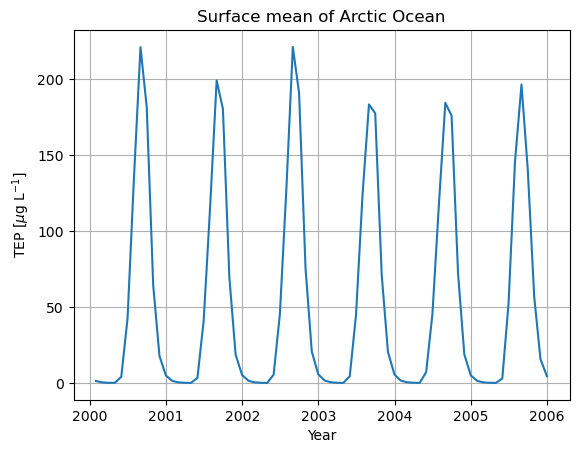

In [130]:
# simple figure of timeseries
fig, ax = plt.subplots()
ax.plot(TEP_AO_Surface_mean.time, TEP_AO_Surface_mean * conv)
ax.set_ylabel(TEP_label)
ax.set_xlabel('Year')
ax.set_title('Surface mean of Arctic Ocean')
ax.grid()

if savefig:
    plt.savefig(savepath + 'TEP_timeseries_Arctic_Ocean_surface_2000_2005.png',
                dpi=dpi, bbox_inches='tight')

plt.show(block=False)                

### Calculate climatology for 2000-2005

In [ ]:
# calculate climatology
# subset to upper 30 m
# group by months and calculate mean
TEP_AO_clim = TEP_AO.sel(nz1=slice(0, 30)).groupby("time.month").mean("time")

if not silent:
    display(TEP_AO_clim)

<xarray.DataArray 'TEP' (month: 12, nod2: 400184, nz1: 4)> Size: 77MB
array([[[ 0.26679996,  0.266718  ,  0.26666138,  0.26512647],
        [ 0.2652496 ,  0.26519498,  0.26513493,  0.26219726],
        [ 0.2636093 ,  0.26356882,  0.263516  ,  0.2586786 ],
        ...,
        [ 0.2836737 ,  0.24292187,  0.17822456,  0.117686  ],
        [ 0.28043348,  0.23928471,  0.17173465,  0.11650094],
        [ 0.27902582,  0.23500021,  0.16662866,  0.11561169]],

       [[ 0.07960454,  0.07959168,  0.07956043,  0.0794959 ],
        [ 0.07885439,  0.07879999,  0.07871422,  0.07861476],
        [ 0.07787348,  0.07779462,  0.07768454,  0.07758553],
        ...,
        [ 0.0866249 ,  0.07605516,  0.06039502,  0.03851595],
        [ 0.08624899,  0.07485045,  0.05866517,  0.03828888],
        [ 0.08600416,  0.07396661,  0.05721857,  0.0380311 ]],

       [[ 0.02403473,  0.02401205,  0.02391405,  0.02373607],
        [ 0.02385567,  0.0238125 ,  0.02367241,  0.02350464],
        [ 0.02362767,  0.02357827,  0.02344019,  0.02328264],
        ...,
...
        [ 9.714831  ,  9.387637  ,  7.658775  ,  3.9383142 ],
        [ 9.41961   ,  9.055157  ,  7.4861636 ,  4.0679297 ],
        [ 9.292681  ,  8.623582  ,  7.3190684 ,  4.2525396 ]],

       [[ 3.4954278 ,  3.4867125 ,  3.480779  ,  3.4733732 ],
        [ 3.4760177 ,  3.4688714 ,  3.4626675 ,  3.4530919 ],
        [ 3.4604003 ,  3.4550016 ,  3.4484985 ,  3.4391525 ],
        ...,
        [ 2.706846  ,  2.525227  ,  1.8715233 ,  1.0907158 ],
        [ 2.6325717 ,  2.4472187 ,  1.817049  ,  1.0997628 ],
        [ 2.6127288 ,  2.3837752 ,  1.7731509 ,  1.1070465 ]],

       [[ 1.0112306 ,  1.0109409 ,  1.0088073 ,  1.0038267 ],
        [ 0.994698  ,  0.9944258 ,  0.99251014,  0.98678637],
        [ 0.9753744 ,  0.97512126,  0.9729304 ,  0.9667924 ],
        ...,
        [ 0.8621611 ,  0.76560706,  0.5382144 ,  0.31428692],
        [ 0.85830754,  0.77081925,  0.52209175,  0.31229028],
        [ 0.860099  ,  0.7787903 ,  0.50769275,  0.31061918]]],
      dtype=float32)
Coordinates:
  * nz1      (nz1) float64 32B 2.5 7.5 15.0 25.0
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: nod2
Attributes:
    description:  Transparent exopolymer particles in sea water
    long_name:    Transparent exopolymer particles in sea water
    units:        [mmol/m3]

The dataset contains now 
- twelve timeoints corresponding to the months. 
- four depth layers spanning the upper 30 m of the water column.

In [ ]:
# calculate mean TEP concentration across Arctic Ocean region
TEP_AO_clim_mean = TEP_AO_clim.mean(dim='nod2').compute()

# calculate standard deviation
TEP_AO_clim_std = TEP_AO_clim.std(dim='nod2').compute()

# name variables within Datsets
TEP_AO_clim_mean.name = 'TEP_mean'
TEP_AO_clim_std.name = 'TEP_std'

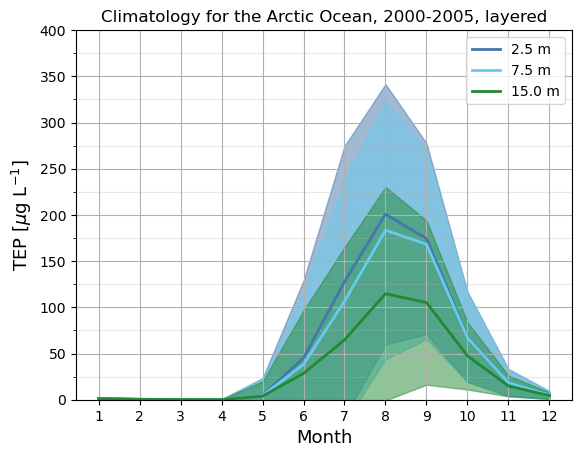

In [ ]:
# plotting climatology

# Paul Tol's bright colors
# blue, cyan, green, yellow, red, pruple, grey
CB_Tol_bright = ['#4477AA', '#66CCEE', '#228833',
                 '#CCBB44', '#EE6677', '#AA3377', '#BBBBBB']

months = TEP_AO_clim.month

lwd = 2
alpha = 0.5
fontsize = 13

ylim = (400)

# figure
fig, ax = plt.subplots()

# surface layer, nz1 = 2.5 m
for i, nz1 in enumerate([2.5, 7.5, 15]):
    m, = ax.plot(months, TEP_AO_clim_mean.sel(nz1=nz1) * conv, '-',
                 color=CB_Tol_bright[i], label=f'{nz1:2.1f} m', linewidth=lwd)
    ax.fill_between(months,
                    (TEP_AO_clim_mean.sel(nz1=nz1) +
                     TEP_AO_clim_std.sel(nz1=nz1)) * conv,
                    (TEP_AO_clim_mean.sel(nz1=nz1) -
                     TEP_AO_clim_std.sel(nz1=nz1)) * conv,
                    color=CB_Tol_bright[i], alpha=alpha)

# ax outline
ax.axhline(y=0, linewidth=.70, linestyle='-', color='k')
ax.set_xlabel('Month', fontsize=fontsize)
ax.set_ylabel(TEP_label, fontsize=fontsize)
ax.set_ylim(0, ylim)
ax.grid()
ax.set_yticks([y for y in range(0, ylim, 25)], minor=True)
ax.yaxis.grid(True, which='minor', alpha=0.3)
ax.set_xticks([x for x in months])  # , minor=True)
ax.legend()
ax.set_title('Climatology for the Arctic Ocean, 2000-2005, layered')

if savefig:
    plt.savefig(savepath + 'TEP_climatology_Arctic_Ocean_layered_2000_2005.png',
                dpi=dpi, bbox_inches='tight')

plt.show(block=False)

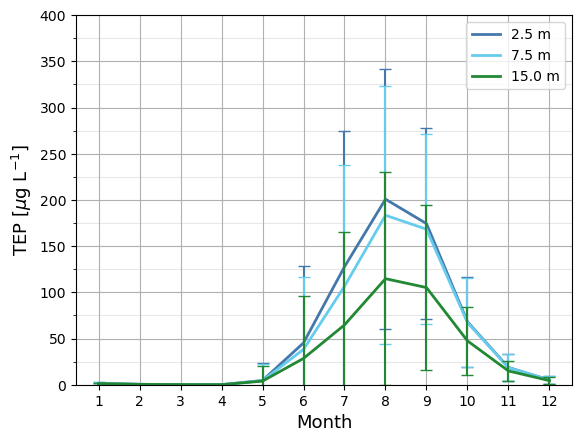

In [ ]:
# same plot for climatology
# now figure with errorbars


# Paul Tol bright colors
# blue, cyan, green, yellow, red, pruple, grey
CB_Tol_bright = ['#4477AA', '#66CCEE', '#228833',
                 '#CCBB44', '#EE6677', '#AA3377', '#BBBBBB']

months = TEP_AO_clim.month

lwd = 2
alpha = 0.5
fontsize = 13

ylim = (400)

# figure
fig, ax = plt.subplots()

# surface layer, nz1 = 2.5 m
for i, nz1 in enumerate([2.5, 7.5, 15]):
    m, = ax.plot(months, TEP_AO_clim_mean.sel(nz1=nz1) * conv, '-',
                 color=CB_Tol_bright[i], label=f'{nz1:2.1f} m', linewidth=lwd)
    ax.errorbar(months, TEP_AO_clim_mean.sel(nz1=nz1) * conv,
                yerr=TEP_AO_clim_std.sel(nz1=nz1) * conv,
                capsize=4, linestyle='', color=CB_Tol_bright[i],
                )

# ax outline
ax.axhline(y=0, linewidth=.70, linestyle='-', color='k')
ax.set_xlabel('Month', fontsize=fontsize)
ax.set_ylabel(TEP_label, fontsize=fontsize)
ax.set_ylim(0, ylim)
ax.grid()
ax.set_yticks([y for y in range(0, ylim, 25)], minor=True)
ax.yaxis.grid(True, which='minor', alpha=0.3)
ax.set_xticks([x for x in months])  # , minor=True)
ax.legend()
ax.set_title('Climatology for the Arctic Ocean, 2000-2005, layered')

plt.show(block=False)

### Calculate trends 
Trends for TEP concentration are calculated for each grid cell. 
Since the ```pyfesom2``` interpolation routine is based on a global grid, the dataset has to be global as well (equal number of mesh points).

In [ ]:
# subset TEP to surface data for 2000-2005
TEP_Surface = TEP_3D_Monthly_1990_2019.TEP.sel(
    time=slice('2000-01', '2005-12')).sel(nz1=2.5)

# subset to contain only May
TEP_Surface_May = TEP_Surface.sel(time=TEP_Surface.time.dt.month.isin([5]))

In [122]:
# linear regression per grid cell
from scipy.stats import linregress

res_May = TEP_Surface_May.polyfit(dim='time', deg=1, skipna=True)

In [ ]:
# specification for interpolation to regular
box = [-180,180,-80,90]
left, right, down, up = box

# resolution
res_factor = 2
lonNumber, latNumber = [360 * res_factor, 180 * res_factor] 

# create meshgrid
lonreg = np.linspace(left, right, lonNumber)
latreg = np.linspace(down, up, latNumber)
lons, lats = np.meshgrid(lonreg, latreg)

# create land-ocean mask based on natural Earth
mask_NaturalEarth = pf.mask_ne(lons, lats)

In [134]:
# control on number of grid cells
mesh.n2d == len(res_May.polyfit_coefficients[0,:])

True

In [124]:
# interpolation based on pyfesom2 
reg = pf.fesom2regular(res_May.polyfit_coefficients[0,:].values, mesh, lons, lats)

# land masking
aux = np.ma.masked_where(mask_NaturalEarth, reg)
res_May_slope = np.ma.masked_equal(aux, 0)

# cyclic points for plotting
res_May_slope_cyc, lon_cyc = pf.add_cyclic_point(res_May_slope, coord=lonreg)

In [125]:
# new meshgrid for plotting
lons_cyc, lats_cyc = np.meshgrid(lon_cyc, latreg)

In [ ]:
def mygrid(m, box=[-180, 180, 65, 90], draw_labels=True,
           gridcolor='lightgray', fontsize=14, labelcolor='black'):
    '''
    Add natural earth fetures, add grid to panel, and set extent to specified lat/lon box.
    '''

    # natural earth feature
    m.add_feature(cfeature.LAND, zorder=1,
                  edgecolor='black', facecolor='darkgray')
    # m.add_feature(cfeature.COASTLINE.with_scale('110m'), linewidth=0.1, color='black')

    # box
    m.set_extent(box, crs=ccrs.PlateCarree())

    # grid
    gl = m.gridlines(draw_labels=draw_labels, dms=True, y_inline=True, alpha=0.8, color=gridcolor,
                     xlabel_style=dict(rotation=0, fontsize=fontsize),
                     ylabel_style=dict(color=labelcolor, fontsize=fontsize))

    if draw_labels:
        # gl.xformatter = ticker.FuncFormatter(lambda x, _: f"{abs(x):.0f}° {'E' if x >= 0 else 'W'}")
        gl.yformatter = ticker.FuncFormatter(
            lambda y, _: f"{abs(y):.0f}° {'N' if y >= 0 else 'S'}")

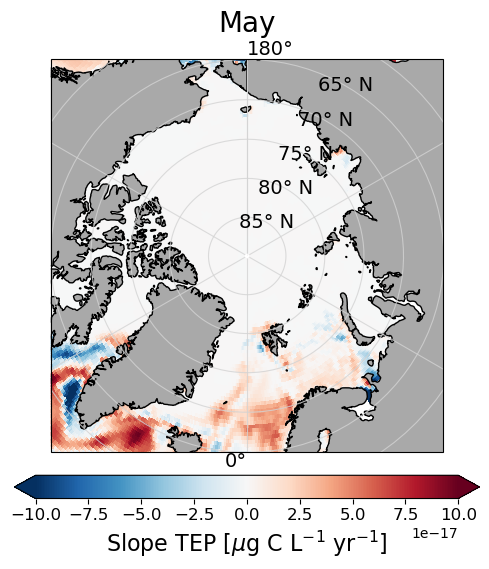

In [ ]:
# plot TEP with specific colorbar
# for months of main blooming, i.e., here only for May
# other months can easily be added as panels and included in subplot_mosaic

# map outline
mapproj = ccrs.NorthPolarStereo()
box = [-180, 180, 68, 90]

# colormap
cmap = 'RdBu_r'

# norm
vmin = -10e-17
vmax = -vmin

# levels = np.arange(-0.02,0.0205,0.0025)
# ticks = np.arange(-0.2,0.21,0.125)
# norm = colors.BoundaryNorm(boundaries=levels, ncolors=256)
norm = None

# formatting
sfmt = ticker.ScalarFormatter(useMathText=True)
sfmt.set_powerlimits((-3, 4))

# figure
fig = plt.figure(figsize=(8, 6))
axes = fig.subplot_mosaic(
    """
            A
            """,
    gridspec_kw={'hspace': 0.02, 'wspace': 0.05},
    subplot_kw=dict(projection=mapproj))

# -----------------------------------------------------
# May
ax1 = axes['A']
m1 = ax1.pcolormesh(lons_cyc, lats_cyc, res_May_slope_cyc,
                    norm=norm,
                    vmin=vmin, vmax=vmax,
                    cmap=cmap,
                    transform=ccrs.PlateCarree())
mygrid(ax1)
ax1.set_title('May', fontsize=20)

# -----------------------------------------------------
# -----------------------------------------------------
# colorbar
cbar = fig.colorbar(m1, ax=[ax1],
                    orientation='horizontal',
                    # ticks = ticks,
                    # format = sfmt,
                    extend='both',
                    fraction=0.1, pad=0.05, shrink=0.75)
cbar.set_label('Slope TEP [$\mu$g C L$^{{-1}}$ yr$^{-1}$]', fontsize=16)
cbar.ax.tick_params(labelsize=12)


# -----------------------------------------------------
if savefig:
    plt.savefig(savepath+'TEP_LinReg_May_2000-2005.png',
                dpi=dpi, bbox_inches='tight')

plt.show(block=False)

````
# Alternative for trends (more statistics)
from scipy.stats import linregress

x = TEP_Surface_May.time.data

# create storage arrays
slopes = []
intercepts = []
r_values = []
p_values = []
std_errs = []

for i in range(len(TEP_Surface_May.nod2.data)):
    print(i)
    y = TEP_Surface_May.data[:,i]
    
    # linear regression
    slope, intercept, r_value, p_value, std_err = linregress(x=x,y=y, nan_policy = 'omit')
    
    # store
    slopes.append(slope)
    intercepts.append(intercept)
    r_values.append(r_value)
    p_values.append(p_value)
    std_errs.append(std_err)
    
TEP_Surface_May_slopes = np.array(slopes)
TEP_Surface_May_intercepts = np.array(intercepts)
TEP_Surface_May_r_values = np.array(r_values)
TEP_Surface_May_p_values = np.array(p_values)
TEP_Surface_May_std_errs = np.array(std_errs)
````

### Calculating volume-weighted mean for specific depth range
Examplary function to obtain volume-weighted data for a specific model variable. 
This function has been adapted from ```pyfesom2``` and used in creating the Zenodo datasets in the specified repository.

In [128]:
def vw_mean_data(data, mesh, uplow=None, meshdiag=None, runid="fesom", mask=None,
                  silent = True, compare = False):
    """Calculate volume weighted mean over the range of depths.

    Parameters
     ----------
     data: xarray.DataArray, numpy.array
        Input data, that can be ether xarray data, or just numpy array,
        with values of 3d tracer variable (on nodes).
        Input should be 3d (time, nodes, levels(nz1))
        The 2D input (to calculate value for only one time step)
        in form of (nodes, levels(nz1)) is possible, but not recomended :)
    mesh: mesh object
        FESOM2 mesh object.
    uplow: list
        if None, all depths will be selected
        if e.g. [2000, 'depth'] all from model depth closest to 200 down to depth will be selected
        if e.g. [0, 700] all between 0 and closest depth to 700 will be selected.
        if e.g. [500, 500] only model level closest to 500 will be selected.
    meshdiag: str
        path to *mesh.diag.nc file, that is created during fesom cold start.
    runid: str
        name of the run. Usually just `fesom`.
    mask: array of bool
        array of boolian values of the same shape as 2D variable.
        True where data are selected.
    silent: bool
        Print diagnostics while processing.
    compare: bool
        Plot comparison of weighted and unweighted mean.

    Returns
    -------
    time series: xarray.DataArray
        time series in dimension (time,nodes) of volume weighted scalar.
    """
    
    if len(data.shape) == 2:
        data = pf.add_timedim(data)
        
    # select corresponding indices
    if uplow is None:
        uplow = [0,100]
    
    indexes = pf.select_depths(uplow, mesh,verbose=np.invert(silent))
    print(f'Selected indexes: {indexes}\nNumber of indexes: {len(indexes)-1}')
    
    # Thickness of layers
    delta_z = np.abs(np.diff(mesh.zlev))
    
    # Mask data if necessary
    if mask is not None:
        data = data[:, mask, :]
        
    # Load mesh area
    #diag = pf.get_meshdiag(mesh, meshdiag, runid)
    diag = xr.open_dataset(mesh.path+'/fesom.mesh.diag.nc')
    
    nod_area = diag.rename_dims({"nl": "nz1", "nod_n": "nod2"}).nod_area
    nod_area.load()

    # Mask mesh area if necessary
    if mask is not None:
        nod_area = nod_area[:, mask]

    # Storage arrays
    total_tracer = xr.zeros_like(data)
    aux_volume = xr.zeros_like(nod_area[0,:])
    #print(np.shape(aux_volume))

    # Calculation per layer, index also contains lower boundary!!!
    for i in indexes[:-1]: 
        if not silent:
            print('Processing depth index {0}'.format(i))
            
        #nod_area_at_level = np.ma.masked_equal(nod_area[i, :].data, 0)
        nod_vol_at_level = np.ma.masked_equal(nod_area[i, :].data, 0) * delta_z[i]
        total_tracer[:,:,i] = data[:, :, i] * nod_vol_at_level[:] 
        aux_volume = aux_volume + nod_vol_at_level
        
        if False:
            print(f'    delta_z: {delta_z[i]}')
            print(f'    sum data: {np.nansum(data[:, :, i])}')
            print(f'    nod_vol_at_level: {np.nansum(nod_vol_at_level)}')

    output = total_tracer.sum(axis=2) / aux_volume #total_volume
    
       
    if not silent:
        print('Output shape: {0}\nmin = {1:3.6f}\nmax = {2:3.6f}'.format(
            np.shape(output),np.nanmin(output), np.nanmax(output)))
        print('mean = {0:3.6f}'.format(np.nanmean(output)))
    
    return output

### Calculating depth integral for specific depth range
Examplary function to obtain depth-integrated data for a specific model variable. 
This function has been adapted from ```pyfesom2``` and used in creating the Zenodo datasets in the specified repository.

In [129]:
def get_depthIintegral_perNode(data, mesh, uplow=None, meshdiag=None, runid="fesom", mask=None,
                  silent = True):
    """Calculate integral of tracer over the range of depth.

    Parameters
     ----------
    data: xarray.DataArray, numpy.array
    mesh: mesh object
    uplow: list
    meshdiag: str
    runid: str
    mask: array of bool
    silent: bool

    Returns
    -------
    time series: xarray.DataArray
        time series in dimension (time,nodes) of integrated scalar.
    """
    
    import pyfesom2 as pf
    import numpy as np
    import xarray as xr
    
    if len(data.shape) == 2:
        data = pf.add_timedim(data)
        
    # select corresponding indices
    if uplow is None:
        uplow = [0,100]
    
    indexes = pf.select_depths(uplow, mesh,verbose=np.invert(silent))
    if not silent:
        print('Total number of selected layers: {0}'.format(len(indexes[:-1])))
        
    # Thickness of layers
    delta_z = np.abs(np.diff(mesh.zlev))
    
    # Mask data if necessary
    if mask is not None:
        data = data[:, mask, :]

    # Storage arrays
    weighted_tracer = xr.zeros_like(data)

    # Calculation per layer, index also contains lower boundary!!!
    for i in indexes[:-1]: 
        if not silent:
            print('Processing depth index {0}'.format(i))
        delta_z_at_level = delta_z[i]
        weighted_tracer[:,:,i] = data[:,:,i] * delta_z_at_level
        
    #integrated_tracer = np.nansum(weighted_tracer, axis = 2)
    integrated_tracer = weighted_tracer.sum(axis = 2)
    
    if not silent:
        print('Output shape: {0}'.format(np.shape(integrated_tracer)))
        
    return integrated_tracer